# Principal Component Analysis
Principal component analysis, or PCA, is a statistical technique to convert high dimensional data to low dimensional data by selecting the most important features that capture maximum information about the dataset. The features are selected on the basis of variance that they cause in the output. The feature that causes highest variance is the first principal component. The feature that is responsible for second highest variance is considered the second principal component, and so on. It is important to mention that principal components do not have any correlation with each other.

# Advantages of PCA
There are two main advantages of dimensionality reduction with PCA.

1. The training time of the algorithms reduces significantly with less number of features.
2. It is not always possible to analyze data in high dimensions. For instance if there are 100 features in a dataset. Total number of scatter plots required to visualize the data would be 100(100-1)2 = 4950. Practically it is not possible to analyze data this way.

# Points to Remember
1. It is imperative to mention that a feature set must be normalized before applying PCA.As principal components will be biased towards features with high variance, leading to false results.
2. PCA is a statistical technique and can only be applied to numeric data. Therefore, categorical features are required to be converted into numerical features before PCA can be applied.

# Implementing PCA with Scikit-Learn

## Importing Libraries

In [86]:
import numpy as np
import pandas as pd

In [87]:
dataset = pd.read_csv("iris.csv")

In [88]:
dataset.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [89]:
names = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'Class']

In [90]:
dataset = dataset.drop(columns=["Id"])

In [91]:
dataset.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [92]:
dataset.columns = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'Class']

In [93]:
dataset.head()

,sepal-length,sepal-width,petal-length,petal-width,Class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Importing Dataset

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
names = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'Class']
dataset = pd.read_csv(url, names=names)
dataset.head()

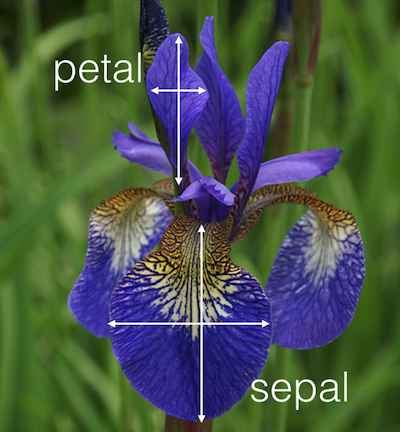

For the following tutorial, we will be working with the famous “Iris” dataset that has been deposited on the UCI machine learning repository
(https://archive.ics.uci.edu/ml/datasets/Iris).

**Reference:** Bache, K. & Lichman, M. (2013). UCI Machine Learning Repository. Irvine, CA: University of California, School of Information and Computer Science.
The iris dataset contains measurements for 150 iris flowers from three different species.

The three classes in the Iris dataset:

Iris-setosa (n=50)
Iris-versicolor (n=50)
Iris-virginica (n=50)
The four features of the Iris dataset:

sepal length in cm
sepal width in cm
petal length in cm
petal width in cm

## Preprocessing 1
The first preprocessing step is to divide the dataset into a feature set and corresponding labels.The script above stores the feature sets into the X variable and the series of corresponding labels in to the y variable.

In [ ]:
X = dataset.drop(columns=['Class'])
y = dataset['Class']

## Preprocessing 2
The next preprocessing step is to divide data into training and test sets. 

In [94]:
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

## Preprocessing 3: Normalization
As mentioned earlier, PCA performs best with a normalized feature set. We will perform standard scalar normalization to normalize our feature set.

In [95]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Applying PCA
Performing PCA using Scikit-Learn is a two-step process:

1. Initialize the PCA class by passing the number of components to the constructor.
2. Call the fit and then transform methods by passing the feature set to these methods. The transform method returns the specified number of principal components.

In [96]:
from sklearn.decomposition import PCA

pca = PCA()
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

In [97]:
explained_variance = pca.explained_variance_ratio_
explained_variance
print("Variance:","\n",explained_variance)

Variance: 
 [0.72226528 0.23974795 0.03338117 0.0046056 ]


We did not specify the number of components in the constructor. Hence, all four of the features in the feature set will be returned for both the training and test sets. 

It can be seen that first principal component is responsible for 72.22% variance. Similarly, the second principal component causes 23.9% variance in the dataset. Collectively we can say that (72.22 + 23.9) 96.21% percent of the classification information contained in the feature set is captured by the first two principal components.

Let's first try to use 1 principal component to train our algorithm.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Training and Making Predictions
In this case we'll use random forest classification for making the predictions.

In [98]:
from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier(max_depth=2, random_state=0)
classifier.fit(X_train, y_train)

# Predicting the Test set results
y_pred = classifier.predict(X_test)

# Performance Evaluation

[[11  0  0]
 [ 0 11  2]
 [ 0  1  5]]
Accuracy0.9


<Axes: >

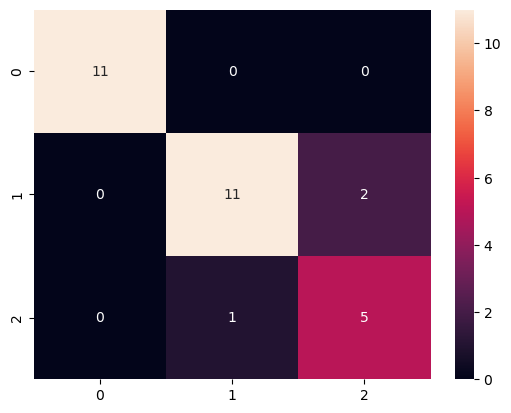

In [99]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

cm = confusion_matrix(y_test, y_pred)
print(cm)
print('Accuracy' + str(accuracy_score(y_test, y_pred)))

import seaborn as sns


sns.heatmap(cm, annot=True)

# Results with 2 Principal Components
Now let's try to evaluate classification performance of the random forest algorithm with 2 principal components.

1. With two principal components the classification accuracy decreases to 83.33% compared to 93.33% for 1 component.
2. With three principal components the classification accuracy again increases to 93.33%
3. The accuracy received with full feature set is for random forest algorithm is also 93.33%.

In [100]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train a classifier on PCA features
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_pca, y_train)

# Predict
y_pred = clf.predict(X_test_pca)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8666666666666667

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       0.91      0.77      0.83        13
 Iris-virginica       0.62      0.83      0.71         6

       accuracy                           0.87        30
      macro avg       0.84      0.87      0.85        30
   weighted avg       0.89      0.87      0.87        30



# Rule of Thumb
A general rule of thumb is to take number of principal of principal components that contribute to significant variance and ignore those with diminishing variance returns. 